# Clase Completa de Estadística

Este notebook combina pruebas de hipótesis y estadísticas analíticas para dictar una clase integral.

## Estadísticas Analíticas

# Sprint 5 - Análisis Estadístico de Datos

## Objetivos

1. Comprender los conceptos básicos de estadística descriptiva y aplicarlos en conjuntos de datos.
2. Explorar la teoría de la probabilidad mediante ejemplos prácticos.
3. Realizar pruebas de hipótesis usando Python.

---

## Esa vieja sensación familiar...

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from math import factorial
from scipy import stats
from scipy import stats as st

## 0. ¿Y si hablamos sobre el aguacate?

<div style="text-align: center;">
    <img src="cate.jpg" alt="Taylor Swift" style="width:50%;"/>
</div>

In [2]:
data =pd.read_csv('avocado.csv')

In [3]:
data.head()

,Unnamed: 0,Date,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region
0,0,2015-12-27,1.33,64236.62,1036.74,54454.85,48.16,8696.87,8603.62,93.25,0.0,conventional,2015,Albany
1,1,2015-12-20,1.35,54876.98,674.28,44638.81,58.33,9505.56,9408.07,97.49,0.0,conventional,2015,Albany
2,2,2015-12-13,0.93,118220.22,794.70,109149.67,130.50,8145.35,8042.21,103.14,0.0,conventional,2015,Albany
3,3,2015-12-06,1.08,78992.15,1132.00,71976.41,72.58,5811.16,5677.40,133.76,0.0,conventional,2015,Albany
4,4,2015-11-29,1.28,51039.60,941.48,43838.39,75.78,6183.95,5986.26,197.69,0.0,conventional,2015,Albany


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18249 entries, 0 to 18248
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0    18249 non-null  int64  
 1   Date          18249 non-null  object 
 2   AveragePrice  18249 non-null  float64
 3   Total Volume  18249 non-null  float64
 4   4046          18249 non-null  float64
 5   4225          18249 non-null  float64
 6   4770          18249 non-null  float64
 7   Total Bags    18249 non-null  float64
 8   Small Bags    18249 non-null  float64
 9   Large Bags    18249 non-null  float64
 10  XLarge Bags   18249 non-null  float64
 11  type          18249 non-null  object 
 12  year          18249 non-null  int64  
 13  region        18249 non-null  object 
dtypes: float64(9), int64(2), object(3)
memory usage: 1.9+ MB


In [5]:
data.shape

(18249, 14)

In [6]:
data.describe()

,Unnamed: 0,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,year
count,18249.000000,18249.000000,1.824900e+04,1.824900e+04,1.824900e+04,1.824900e+04,1.824900e+04,1.824900e+04,1.824900e+04,18249.000000,18249.000000
mean,24.232232,1.405978,8.506440e+05,2.930084e+05,2.951546e+05,2.283974e+04,2.396392e+05,1.821947e+05,5.433809e+04,3106.426507,2016.147899
std,15.481045,0.402677,3.453545e+06,1.264989e+06,1.204120e+06,1.074641e+05,9.862424e+05,7.461785e+05,2.439660e+05,17692.894652,0.939938
min,0.000000,0.440000,8.456000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,2015.000000
25%,10.000000,1.100000,1.083858e+04,8.540700e+02,3.008780e+03,0.000000e+00,5.088640e+03,2.849420e+03,1.274700e+02,0.000000,2015.000000
50%,24.000000,1.370000,1.073768e+05,8.645300e+03,2.906102e+04,1.849900e+02,3.974383e+04,2.636282e+04,2.647710e+03,0.000000,2016.000000
75%,38.000000,1.660000,4.329623e+05,1.110202e+05,1.502069e+05,6.243420e+03,1.107834e+05,8.333767e+04,2.202925e+04,132.500000,2017.000000
max,52.000000,3.250000,6.250565e+07,2.274362e+07,2.047057e+07,2.546439e+06,1.937313e+07,1.338459e+07,5.719097e+06,551693.650000,2018.000000


## 1. Estadística Descriptiva

### 1.1 Tipos de Variables

**Teoría:**
- **Cuantitativas:** Representan cantidades y se pueden medir numéricamente. Ejemplo: Precio promedio.
- **Cualitativas:** Representan categorías o atributos. Ejemplo: Tipo de aguacate ("conventional" o "organic").
- **Discretas:** Variables cuantitativas que solo toman valores enteros. Ejemplo: Año.
- **Continuas:** Variables cuantitativas que pueden tomar cualquier valor dentro de un rango. Ejemplo: Precio promedio.

**Práctica:**

In [8]:
# Ejemplo con datos del archivo cargado
print("Tipos de datos:")
print(data.info())

Tipos de datos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18249 entries, 0 to 18248
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0    18249 non-null  int64  
 1   Date          18249 non-null  object 
 2   AveragePrice  18249 non-null  float64
 3   Total Volume  18249 non-null  float64
 4   4046          18249 non-null  float64
 5   4225          18249 non-null  float64
 6   4770          18249 non-null  float64
 7   Total Bags    18249 non-null  float64
 8   Small Bags    18249 non-null  float64
 9   Large Bags    18249 non-null  float64
 10  XLarge Bags   18249 non-null  float64
 11  type          18249 non-null  object 
 12  year          18249 non-null  int64  
 13  region        18249 non-null  object 
dtypes: float64(9), int64(2), object(3)
memory usage: 1.9+ MB
None


In [9]:
# Ejemplo de conteo de valores para variables cualitativas
print("Tipos de aguacate:")
print(data['type'].value_counts())

Tipos de aguacate:
type
conventional    9126
organic         9123
Name: count, dtype: int64


In [10]:
print("Tipos de aguacate:")
print(data['region'].value_counts())

Tipos de aguacate:
region
Albany                 338
Sacramento             338
Northeast              338
NorthernNewEngland     338
Orlando                338
Philadelphia           338
PhoenixTucson          338
Pittsburgh             338
Plains                 338
Portland               338
RaleighGreensboro      338
RichmondNorfolk        338
Roanoke                338
SanDiego               338
Atlanta                338
SanFrancisco           338
Seattle                338
SouthCarolina          338
SouthCentral           338
Southeast              338
Spokane                338
StLouis                338
Syracuse               338
Tampa                  338
TotalUS                338
West                   338
NewYork                338
NewOrleansMobile       338
Nashville              338
Midsouth               338
BaltimoreWashington    338
Boise                  338
Boston                 338
BuffaloRochester       338
California             338
Charlotte              338
Ch

### 1.2 Histogramas de Frecuencia

**Teoría:**
Los histogramas muestran la distribución de una variable cuantitativa dividiendo los datos en intervalos ("bins").

In [11]:
# Crear histogramas con diferentes configuraciones de bins

In [7]:
data.head()

,Unnamed: 0,Date,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region
0,0,2015-12-27,1.33,64236.62,1036.74,54454.85,48.16,8696.87,8603.62,93.25,0.0,conventional,2015,Albany
1,1,2015-12-20,1.35,54876.98,674.28,44638.81,58.33,9505.56,9408.07,97.49,0.0,conventional,2015,Albany
2,2,2015-12-13,0.93,118220.22,794.70,109149.67,130.50,8145.35,8042.21,103.14,0.0,conventional,2015,Albany
3,3,2015-12-06,1.08,78992.15,1132.00,71976.41,72.58,5811.16,5677.40,133.76,0.0,conventional,2015,Albany
4,4,2015-11-29,1.28,51039.60,941.48,43838.39,75.78,6183.95,5986.26,197.69,0.0,conventional,2015,Albany


<Axes: ylabel='Frequency'>

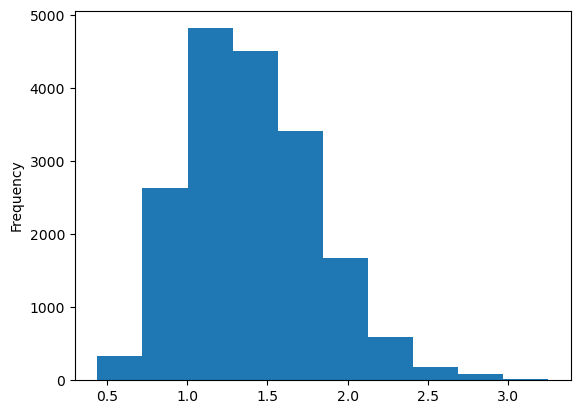

In [9]:
data['AveragePrice'].plot(kind='hist')

In [13]:
# sorted(data["AveragePrice"].unique())

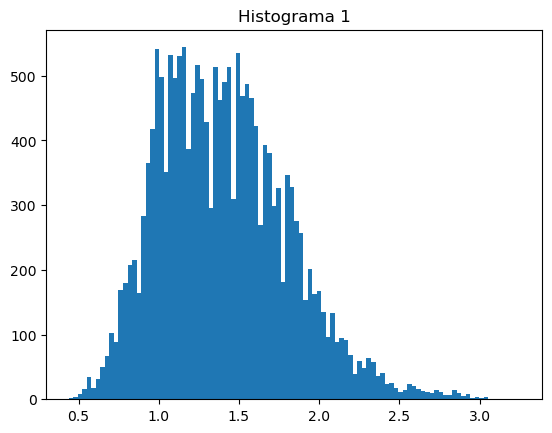

In [27]:
# Primera configuración
plt.hist(data['AveragePrice'], bins=100)
plt.title('Histograma 1')
plt.show()

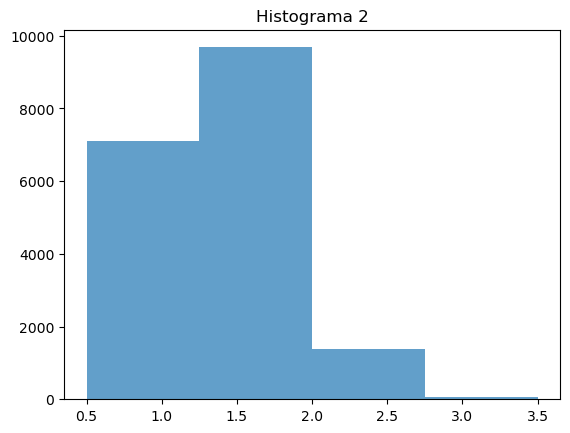

In [15]:
# Segunda configuración
plt.hist(data['AveragePrice'], bins=[0.5, 1.25, 2.0, 2.75, 3.5], alpha=0.7)
plt.title('Histograma 2')

plt.show()

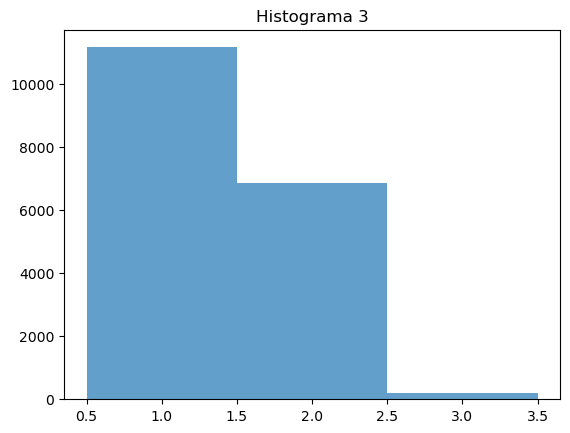

In [16]:
# Tercera configuración
plt.hist(data['AveragePrice'], bins=[0.5, 1.5, 2.5, 3.5], alpha=0.7)
plt.title('Histograma 3')

plt.show()

### 1.3 Boxplots

**Teoría:**
Un boxplot resume la distribución de los datos mediante cinco números clave: mínimo, primer cuartil, mediana, tercer cuartil y máximo. También identifica valores atípicos.



In [17]:
data.describe()

,Unnamed: 0,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,year
count,18249.000000,18249.000000,1.824900e+04,1.824900e+04,1.824900e+04,1.824900e+04,1.824900e+04,1.824900e+04,1.824900e+04,18249.000000,18249.000000
mean,24.232232,1.405978,8.506440e+05,2.930084e+05,2.951546e+05,2.283974e+04,2.396392e+05,1.821947e+05,5.433809e+04,3106.426507,2016.147899
std,15.481045,0.402677,3.453545e+06,1.264989e+06,1.204120e+06,1.074641e+05,9.862424e+05,7.461785e+05,2.439660e+05,17692.894652,0.939938
min,0.000000,0.440000,8.456000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,2015.000000
25%,10.000000,1.100000,1.083858e+04,8.540700e+02,3.008780e+03,0.000000e+00,5.088640e+03,2.849420e+03,1.274700e+02,0.000000,2015.000000
50%,24.000000,1.370000,1.073768e+05,8.645300e+03,2.906102e+04,1.849900e+02,3.974383e+04,2.636282e+04,2.647710e+03,0.000000,2016.000000
75%,38.000000,1.660000,4.329623e+05,1.110202e+05,1.502069e+05,6.243420e+03,1.107834e+05,8.333767e+04,2.202925e+04,132.500000,2017.000000
max,52.000000,3.250000,6.250565e+07,2.274362e+07,2.047057e+07,2.546439e+06,1.937313e+07,1.338459e+07,5.719097e+06,551693.650000,2018.000000


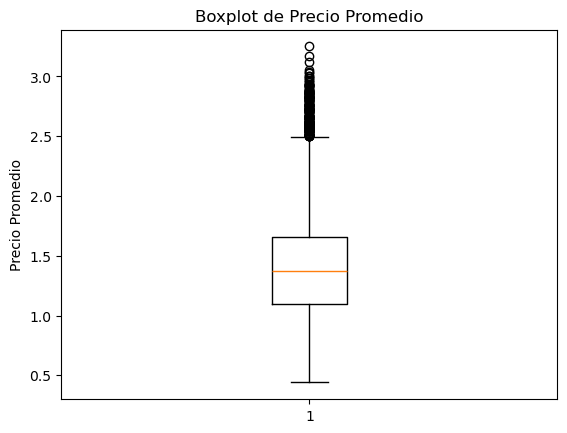

In [18]:
# Crear un boxplot del precio promedio
plt.boxplot(data['AveragePrice'])
plt.title('Boxplot de Precio Promedio')
plt.ylabel('Precio Promedio')
plt.show()

_¿Recuerdas formatear texto?_

In [19]:
# Cálculo adicional: distancia media a la media
mean_value = data['AveragePrice'].mean()
spacing_all = data['AveragePrice'] - mean_value
spacing_all_mean = spacing_all.mean()

print(f"Distancia media a la media: {spacing_all_mean}")

Distancia media a la media: 4.983805697698111e-17


### 1.4 Varianza, Covarianza y Desviación Estándar


**Teoría:**
- **Varianza:** Mide cuánta variación hay en los datos.
- **Desviación estándar:** Es la raíz cuadrada de la varianza y representa la dispersión de los datos respecto a la media.
- **Covarianza:** Indica cómo dos variables cambian juntas.

In [20]:
data.describe()

,Unnamed: 0,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,year
count,18249.000000,18249.000000,1.824900e+04,1.824900e+04,1.824900e+04,1.824900e+04,1.824900e+04,1.824900e+04,1.824900e+04,18249.000000,18249.000000
mean,24.232232,1.405978,8.506440e+05,2.930084e+05,2.951546e+05,2.283974e+04,2.396392e+05,1.821947e+05,5.433809e+04,3106.426507,2016.147899
std,15.481045,0.402677,3.453545e+06,1.264989e+06,1.204120e+06,1.074641e+05,9.862424e+05,7.461785e+05,2.439660e+05,17692.894652,0.939938
min,0.000000,0.440000,8.456000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,2015.000000
25%,10.000000,1.100000,1.083858e+04,8.540700e+02,3.008780e+03,0.000000e+00,5.088640e+03,2.849420e+03,1.274700e+02,0.000000,2015.000000
50%,24.000000,1.370000,1.073768e+05,8.645300e+03,2.906102e+04,1.849900e+02,3.974383e+04,2.636282e+04,2.647710e+03,0.000000,2016.000000
75%,38.000000,1.660000,4.329623e+05,1.110202e+05,1.502069e+05,6.243420e+03,1.107834e+05,8.333767e+04,2.202925e+04,132.500000,2017.000000
max,52.000000,3.250000,6.250565e+07,2.274362e+07,2.047057e+07,2.546439e+06,1.937313e+07,1.338459e+07,5.719097e+06,551693.650000,2018.000000


In [21]:
# Calcular la varianza y desviación estándar
variance = np.var(data['AveragePrice'])
std_deviation = np.std(data['AveragePrice'])

print(f"Varianza: {variance}")
print(f"Desviación Estándar: {std_deviation}")

Varianza: 0.16213952301460038
Desviación Estándar: 0.40266552250546656


In [22]:
# Calcular la covarianza entre precio promedio y volumen total
covariance_matrix = np.cov(data['AveragePrice'], data['Total Volume'])
covariance = covariance_matrix[0][1]

In [23]:
print(f"Covarianza: {covariance}")

Covarianza: -268053.3716412471


---

## 2. Teoría de la Probabilidad

### 2.1 Predicciones Simples

<script type="text/javascript" async
  src="https://cdnjs.cloudflare.com/ajax/libs/mathjax/2.7.7/MathJax.js?config=TeX-MML-AM_CHTML">
</script>

<p>La probabilidad mide la posibilidad de que ocurra un evento. Se calcula como:</p>
<p>
  \[ P(A) = \frac{\text{Número de casos favorables}}{\text{Número total de casos}} \]
</p>


In [24]:
# Probabilidad de que el tipo sea "organic"
organic_count = len(data[data['type'] == 'organic'])
total_count = len(data)
probability = organic_count / total_count

print(f"Probabilidad de que el aguacate sea 'organic': {probability}")

Probabilidad de que el aguacate sea 'organic': 0.49991780371527206


### 2.2 Combinatoria y Distribución Binomial

**Teoría:**
- **Factoriales:** Utilizados para calcular combinaciones y permutaciones.
- **Combinaciones:** Número de formas de seleccionar elementos sin importar el orden.
- **Distribución binomial:** Modela la probabilidad de un número fijo de éxitos en intentos independientes.

In [25]:
# Calcular factorial
n = 5
k = 3
combinations = factorial(n) / (factorial(k) * factorial(n-k))
print(f"Combinaciones: {combinations}")

Combinaciones: 10.0


In [26]:
# Probabilidad binomial
p = 0.6
q = 0.4
n = 80
k = 50
probability = factorial(n) / (factorial(k) * factorial(n-k)) * (p ** k) * (q ** (n-k))
print(f"Probabilidad binomial: {probability}")

Probabilidad binomial: 0.0826713508623046


---

### 2.3 Distribución Normal

**Teoría:**
La distribución normal es simétrica y se caracteriza por su media y desviación estándar. Es útil para modelar muchos fenómenos naturales.

In [27]:
mu = 100500
sigma = 3500
more_threshold = 111000
fewer_threshold = 92000

p_more_visitors = 1 - st.norm(mu, sigma).cdf(more_threshold)
p_fewer_visitors = st.norm(mu, sigma).cdf(fewer_threshold)

print(f"Probabilidad de más de {more_threshold} visitantes: {p_more_visitors}")
print(f"Probabilidad de menos de {fewer_threshold} visitantes: {p_fewer_visitors}")

Probabilidad de más de 111000 visitantes: 0.0013498980316301035
Probabilidad de menos de 92000 visitantes: 0.0075792194387197245


## 3. Pruebas de Hipótesis

### 3.1 Teorema del Límite Central

**Teoría:**
El Teorema del Límite Central establece que la distribución de la media de una muestra aleatoria de datos se aproxima a una distribución normal a medida que el tamaño de la muestra aumenta.


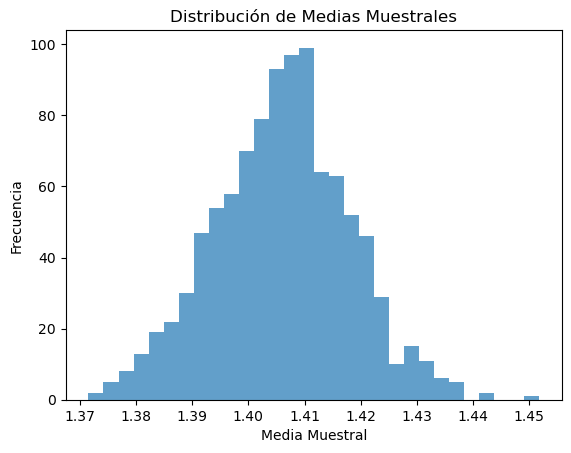

In [34]:
sample_means = [data['AveragePrice'].sample(1000).mean() for _ in range(1000)]
plt.hist(sample_means, bins=30, alpha=0.7)
plt.title('Distribución de Medias Muestrales')
plt.xlabel('Media Muestral')
plt.ylabel('Frecuencia')
plt.show()

### 3.2 Hipótesis de Dos Colas y Una Cola

**Teoría:**
Las hipótesis de dos colas evalúan si una medida es diferente de un valor específico, mientras que las de una cola evalúan si es mayor o menor.

In [31]:
# Prueba de dos colas
hypothesis_value = 1.5
alpha = 0.05
results = stats.ttest_1samp(data['AveragePrice'], hypothesis_value)
print(f"Valor p (dos colas): {results.pvalue}")

# Prueba de una cola
if results.pvalue / 2 < alpha and data['AveragePrice'].mean() > hypothesis_value:
    print("Rechazamos la hipótesis nula (una cola)")
else:
    print("No podemos rechazar la hipótesis nula (una cola)")

Valor p (dos colas): 1.1403055379420951e-212
No podemos rechazar la hipótesis nula (una cola)


### 3.3 Comparación de Medias

**Teoría:**
Se compara la media de dos grupos independientes o emparejados para evaluar diferencias significativas.

In [33]:
data[data['type'] == 'organic'].describe()

,Unnamed: 0,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,year
count,9123.000000,9123.000000,9.123000e+03,9123.000000,9123.000000,9123.000000,9.123000e+03,9123.000000,9123.000000,9123.000000,9123.000000
mean,24.227776,1.653999,4.781121e+04,7311.281600,15411.857724,266.254582,2.481765e+04,17613.474543,7202.982659,1.197164,2016.147868
std,15.478839,0.363502,1.424069e+05,23501.552849,45729.357670,1117.611580,8.185146e+04,60820.415023,26621.208199,14.727286,0.939961
min,0.000000,0.440000,8.456000e+01,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,2015.000000
25%,10.000000,1.420000,4.779910e+03,157.915000,675.560000,0.000000,1.685915e+03,776.625000,4.440000,0.000000,2015.000000
50%,24.000000,1.630000,1.083576e+04,911.460000,3082.620000,0.000000,5.096240e+03,2863.330000,387.550000,0.000000,2016.000000
75%,38.000000,1.870000,3.008704e+04,4354.415000,9880.200000,30.270000,1.437976e+04,9962.555000,2991.820000,0.000000,2017.000000
max,52.000000,3.250000,1.814930e+06,361996.840000,680037.450000,26765.780000,1.124622e+06,944572.500000,561530.390000,510.410000,2018.000000


In [32]:
data[data['type'] == 'conventional'].describe()

,Unnamed: 0,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,year
count,9126.000000,9126.000000,9.126000e+03,9.126000e+03,9.126000e+03,9.126000e+03,9.126000e+03,9.126000e+03,9.126000e+03,9126.000000,9126.000000
mean,24.236686,1.158040,1.653213e+06,5.786116e+05,5.748053e+05,4.540580e+04,4.543901e+05,3.467218e+05,1.014577e+05,6210.635065,2016.147929
std,15.484096,0.263041,4.747892e+06,1.742501e+06,1.655582e+06,1.485750e+05,1.358741e+06,1.027420e+06,3.374545e+05,24631.904345,0.939968
min,0.000000,0.460000,3.369968e+04,7.206000e+01,1.518000e+03,0.000000e+00,3.047170e+03,1.119180e+03,0.000000e+00,0.000000,2015.000000
25%,10.000000,0.980000,1.989086e+05,3.193538e+04,5.091885e+04,5.568800e+02,5.724793e+04,4.329632e+04,2.308108e+03,0.000000,2015.000000
50%,24.000000,1.130000,4.083255e+05,1.047067e+05,1.361147e+05,6.035945e+03,9.889676e+04,7.572726e+04,1.458263e+04,122.255000,2016.000000
75%,38.000000,1.320000,1.030992e+06,3.647169e+05,4.151696e+05,2.118183e+04,2.916959e+05,2.043966e+05,5.991083e+04,2409.215000,2017.000000
max,52.000000,2.220000,6.250565e+07,2.274362e+07,2.047057e+07,2.546439e+06,1.937313e+07,1.338459e+07,5.719097e+06,551693.650000,2018.000000


In [28]:
# Comparación de medias de dos grupos independientes
results = stats.ttest_ind(data[data['type'] == 'organic']['AveragePrice'],
                          data[data['type'] == 'conventional']['AveragePrice'])
alpha = 0.05
print(f"Valor p: {results.pvalue}")
if results.pvalue < alpha:
    print("Rechazamos la hipótesis nula: las medias son diferentes.")
else:
    print("No podemos rechazar la hipótesis nula: las medias no son significativamente diferentes.")

Valor p: 0.0
Rechazamos la hipótesis nula: las medias son diferentes.


## Pruebas de Hipótesis

# Probabilidad y Estadística en Python

Este notebook cubre los fundamentos de combinatoria, probabilidad, distribuciones y pruebas de hipótesis en Python.
Incluye explicaciones teóricas, fórmulas y ejemplos prácticos con código bien documentado.

## 1. Fundamentos de Combinatoria y Probabilidad

### 1.1 Factoriales

El **factorial** de un número entero positivo `n`, representado como `n!`, se define como:

$$ 
n! = n \times (n-1) \times (n-2) \times \cdots \times 1 
$$


Por convención, se define que `0! = 1`.

Se usa en combinatoria para contar permutaciones y combinaciones.

In [3]:
# Importar la función factorial
from math import factorial

# Calcular el factorial de 3
n = 5
print(f'El factorial de {n} es:', factorial(n))

El factorial de 5 es: 120


### 1.2 Combinaciones

Una combinación es la selección de `k` elementos de un conjunto de `n` elementos sin importar el orden.

La fórmula para calcular combinaciones es:

$$
C(n, k) = \frac{n!}{k!(n-k)!}
$$

In [4]:
# Calcular combinaciones
n = 5  # Número total de elementos
k = 2  # Número de elementos a elegir

combinations = factorial(n) / (factorial(k) * factorial(n - k))
print(f'El número de formas de elegir {k} elementos de {n} es:', combinations)

El número de formas de elegir 2 elementos de 5 es: 10.0


### 1.3 Distribuciones de Datos

Las distribuciones de datos nos permiten agrupar valores en categorías para analizarlos mejor.
A continuación, organizamos calificaciones de exámenes en categorías.

In [5]:
import numpy as np

# Datos de calificaciones
exam_results = np.array([
    42, 56, 59, 76, 43, 34, 62, 51, 50, 65,
    66, 50, 46, 5, 79, 99, 51, 26, 35, 8,
    34, 47, 64, 58, 61, 12, 30, 63, 20, 68
])

# Diccionario para categorizar los datos
summarized_data = {'excellent': 0, 'good': 0, 'average': 0, 'passable': 0, 'failed': 0}

# Clasificación de resultados
for score in exam_results:
    if score >= 90:
        summarized_data['excellent'] += 1
    elif score >= 70:
        summarized_data['good'] += 1
    elif score >= 50:
        summarized_data['average'] += 1
    elif score >= 20:
        summarized_data['passable'] += 1
    else:
        summarized_data['failed'] += 1

# Mostrar resultados
for category, count in summarized_data.items():
    print(f'{category}: {count}')

excellent: 1
good: 2
average: 14
passable: 10
failed: 3


## 2. Distribución Binomial

La **distribución binomial** modela el número de éxitos en `n` ensayos independientes donde cada ensayo tiene probabilidad `p` de éxito.

Su fórmula es:

$$
P(k) = C(n, k) p^k (1 - p)^{n - k}
$$

In [4]:
# Calcular una probabilidad binomial
from math import factorial

p = 0.6  # Probabilidad de éxito
q = 0.4  # Probabilidad de fallo
n = 80   # Número total de clientes
k = 50   # Número de clientes que compran

probability = (factorial(n) / (factorial(k) * factorial(n - k))) * (p ** k) * (q ** (n - k))
print(f'Probabilidad de que exactamente {k} de {n} clientes compren:', probability)

Probabilidad de que exactamente 50 de 80 clientes compren: 0.0826713508623046


## 3. Distribución Normal

La **distribución normal** se usa para modelar variables continuas con una media `μ` y desviación estándar `σ`.

Se define por la función de densidad de probabilidad:

$$
f(x) = \frac{1}{\sigma \sqrt{2\pi}} e^{-\frac{(x - \mu)^2}{2\sigma^2}}
$$

In [7]:
from scipy import stats as st

# Parámetros de la distribución
mu = 5000  # Media
sigma = 1500  # Desviación estándar
desired_cost = 3000  # Valor a evaluar

# Probabilidad acumulada
probability = st.norm(mu, sigma).cdf(desired_cost)
print(f'Probabilidad de que el costo sea menor a {desired_cost}:', probability)

Probabilidad de que el costo sea menor a 3000: 0.09121121972586788


## 4. Pruebas de Hipótesis

Las pruebas de hipótesis nos ayudan a determinar si una afirmación sobre una población es válida con cierto nivel de confianza.

Se usan valores `p` para decidir si rechazamos la hipótesis nula `H0`.

In [6]:
from scipy import stats as st
import pandas as pd

# Datos de prueba
scooters = pd.Series([15, 31, 10, 21, 21, 32, 30, 25, 21, 28])
optimal_value = 30  # Valor de referencia
alpha = 0.05  # Nivel de significación

# Prueba t de una muestra
results = st.ttest_1samp(scooters, optimal_value)
print('Valor p:', results.pvalue)

if results.pvalue < alpha:
    print('Rechazamos la hipótesis nula')
else:
    print('No podemos rechazar la hipótesis nula')

Valor p: 0.0176168256271105
Rechazamos la hipótesis nula


# Probabilidad y Estadística en Python

Se han añadido más ejercicios y explicaciones detalladas para hacer esta clase más extensa y completa.

## 1.4 Permutaciones

Las **permutaciones** son el número de formas en que podemos organizar un conjunto de `n` elementos en `k` posiciones considerando el orden.

La fórmula es:

$$
P(n, k) = \frac{n!}{(n-k)!}
$$

In [7]:
# Calcular permutaciones
from math import factorial

n = 5  # Número total de elementos
k = 3  # Número de elementos a ordenar

permutations = factorial(n) / factorial(n - k)
print(f'El número de formas de ordenar {k} elementos de {n} es:', permutations)

El número de formas de ordenar 3 elementos de 5 es: 60.0


## 1.5 Ejercicio de combinaciones y permutaciones

**Ejercicio:**
En una carrera de 8 participantes, ¿de cuántas maneras pueden ganar los 3 primeros lugares?

In [8]:
# Solución al ejercicio de combinaciones y permutaciones
n = 8  # Total de corredores
k = 3  # Posiciones en el podio

ways_to_win = factorial(n) / factorial(n - k)
print(f'Número de maneras de ganar los 3 primeros lugares:', ways_to_win)

Número de maneras de ganar los 3 primeros lugares: 336.0


## 2.1 Distribución Binomial con más ejemplos

**Ejercicio:**
Si lanzamos una moneda 10 veces, ¿cuál es la probabilidad de obtener exactamente 6 caras?

In [9]:
# Probabilidad binomial en un lanzamiento de moneda
p = 0.5  # Probabilidad de cara
q = 1 - p  # Probabilidad de cruz
n = 10  # Número total de lanzamientos
k = 6  # Número de éxitos (caras)

probability = (factorial(n) / (factorial(k) * factorial(n - k))) * (p ** k) * (q ** (n - k))
print(f'Probabilidad de obtener exactamente {k} caras en {n} lanzamientos:', probability)

Probabilidad de obtener exactamente 6 caras en 10 lanzamientos: 0.205078125


## 3.1 Distribución Normal con Gráficos

Para visualizar la distribución normal, generaremos una gráfica con valores aleatorios.

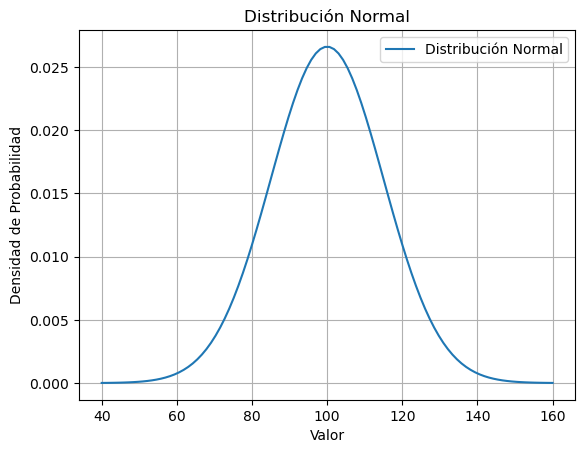

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Parámetros
mu = 100  # Media
sigma = 15  # Desviación estándar

# Generar datos
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 100)
y = norm.pdf(x, mu, sigma)

# Graficar la distribución normal
plt.plot(x, y, label='Distribución Normal')
plt.title('Distribución Normal')
plt.xlabel('Valor')
plt.ylabel('Densidad de Probabilidad')
plt.legend()
plt.grid()
plt.show()

## 4.1 Pruebas de Hipótesis usando 1samp

**Ejercicio:**
Un profesor afirma que el tiempo promedio de estudio de sus alumnos es de 5 horas diarias.
Para comprobar esto, toma una muestra aleatoria de 30 estudiantes y registra el tiempo de estudio.
Realizaremos una prueba de hipótesis para verificar esta afirmación.

In [11]:
from scipy import stats as st
import numpy as np

# Datos de estudio de 30 alumnos
study_hours = np.array([4.5, 5.2, 6.1, 4.8, 5.0, 5.3, 5.1, 4.9, 5.6, 6.0, 
                         4.7, 5.8, 5.4, 5.2, 5.0, 5.1, 4.9, 5.3, 5.7, 5.5,
                         5.6, 4.9, 5.4, 5.2, 5.1, 5.8, 4.6, 5.0, 5.3, 5.7])

mu_claimed = 5  # Hipótesis del profesor
alpha = 0.05  # Nivel de significación

# Prueba t de una muestra
results = st.ttest_1samp(study_hours, mu_claimed)
print('Valor p:', results.pvalue)

if results.pvalue < alpha:
    print('Rechazamos la hipótesis nula: el tiempo de estudio es diferente de 5 horas')
else:
    print('No podemos rechazar la hipótesis nula: el tiempo de estudio es de 5 horas')

Valor p: 0.0016711217842071207
Rechazamos la hipótesis nula: el tiempo de estudio es diferente de 5 horas


# Resumen y Conclusiones


- Fundamentos de combinatoria: factoriales, combinaciones y permutaciones.
- Distribuciones de probabilidad: binomial y normal.
- Pruebas de hipótesis en diferentes escenarios.
